## Import Libraries

In [1]:
# =========================================
# Import Libraries
# =========================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import shutil
import json
import imghdr

from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers
from tensorflow.keras import losses

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

2026-05-13 09:42:50.673272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778665370.868150      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778665370.921164      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778665371.355759      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778665371.355803      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778665371.355805      57 computation_placer.cc:177] computation placer alr

In [2]:

DATASET_PATH = "/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")

VAL_PATH = os.path.join(DATASET_PATH, "val")

TEST_PATH = os.path.join(DATASET_PATH, "test")

In [3]:

IMAGE_SIZE = (224, 224)

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

BATCH_SIZE = 32

EPOCHS = 50

NUM_CLASSES = 4

In [4]:
print(os.listdir(TRAIN_PATH))

['UNKNOWN', 'PNEUMONIA', 'TUBERCULOSIS', 'NORMAL']


In [5]:
CLASS_NAMES = [
    "UNKNOWN",
    "PNEUMONIA",
    "TUBERCULOSIS",
    "NORMAL"
]

In [6]:

for cls in CLASS_NAMES:

    train_count = len(
        os.listdir(
            os.path.join(TRAIN_PATH, cls)
        )
    )

    val_count = len(
        os.listdir(
            os.path.join(VAL_PATH, cls)
        )
    )

    test_count = len(
        os.listdir(
            os.path.join(TEST_PATH, cls)
        )
    )

    print(f"\nClass: {cls}")

    print(f"Train Images: {train_count}")

    print(f"Validation Images: {val_count}")

    print(f"Test Images: {test_count}")


Class: UNKNOWN
Train Images: 1155
Validation Images: 67
Test Images: 135

Class: PNEUMONIA
Train Images: 3633
Validation Images: 213
Test Images: 427

Class: TUBERCULOSIS
Train Images: 3573
Validation Images: 207
Test Images: 417

Class: NORMAL
Train Images: 4667
Validation Images: 274
Test Images: 548


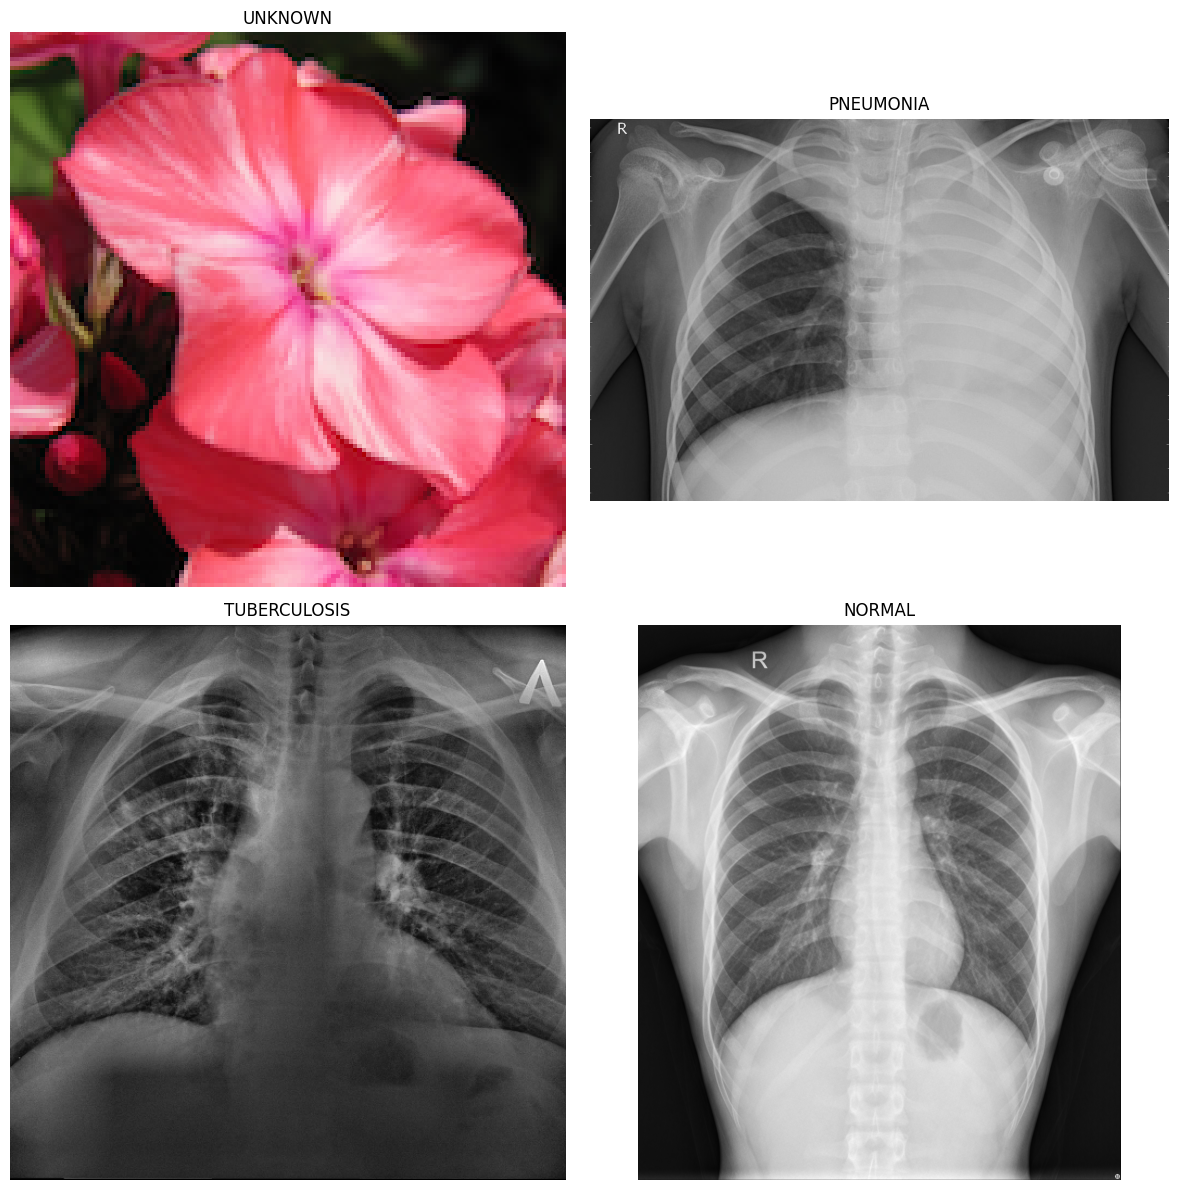

In [7]:
# =========================================
# Visualize Dataset
# =========================================

plt.figure(figsize=(12,12))

for i, cls in enumerate(CLASS_NAMES):

    class_path = os.path.join(TRAIN_PATH, cls)

    random_image = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        random_image
    )

    image = plt.imread(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image, cmap='gray')

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
import os
import imghdr

# =========================================
# Remove Invalid Images
# =========================================

def check_invalid_images(directory):

    valid_extensions = {
        "jpeg",
        "jpg",
        "png"
    }

    invalid_images = []

    for root, dirs, files in os.walk(directory):

        for file in files:

            file_path = os.path.join(root, file)

            try:

                img_type = imghdr.what(file_path)

                if img_type not in valid_extensions:

                    invalid_images.append(file_path)

            except Exception as e:

                invalid_images.append(file_path)

    print(f"\nFound {len(invalid_images)} invalid images\n")

    for img in invalid_images[:20]:

        print(img)


check_invalid_images(TRAIN_PATH)

check_invalid_images(VAL_PATH)

check_invalid_images(TEST_PATH)


Found 284 invalid images

/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/bike_203.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/carsgraz_069.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/carsgraz_120.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/carsgraz_420.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/bike_254.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/carsgraz_105.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/carsgraz_115.bmp
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train/UNKNOWN/bike_222.bmp
/kaggle/input/dat

In [9]:
# =========================================
# Load Dataset
# =========================================

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    TRAIN_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    VAL_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(

    TEST_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 13028 files belonging to 4 classes.


I0000 00:00:1778665552.921296      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 761 files belonging to 4 classes.
Found 1527 files belonging to 4 classes.


In [10]:
# =========================================
# Data Augmentation
# =========================================

data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1),

    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )

])

In [11]:
# =========================================
# Optimize Dataset
# =========================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [12]:
# =========================================
# Build Model
# =========================================

base_model = EfficientNetB0(

    include_top=False,

    weights='imagenet',

    input_shape=(224,224,3)

)

base_model.trainable = False


model = Sequential([

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )

])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
# =========================================
# Compile Model
# =========================================

model.compile(

    optimizer=optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=losses.SparseCategoricalCrossentropy(),

    metrics=["accuracy"]

)

In [14]:
# =========================================
# Compile Model
# =========================================

model.compile(

    optimizer=optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=losses.SparseCategoricalCrossentropy(),

    metrics=["accuracy"]

)

In [15]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(

    monitor='val_accuracy',

    patience=8,

    restore_best_weights=True

)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3

)

checkpoint = callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor='val_accuracy',

    save_best_only=True

)

In [16]:
# =========================================
# Train Model
# =========================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/50


E0000 00:00:1778665567.023594      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778665570.742235     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


408/408 ━━━━━━━━━━━━━━━━━━━━ 91s 187ms/step - accuracy: 0.7086 - loss: 0.8104 - val_accuracy: 0.8660 - val_loss: 0.3041 - learning_rate: 0.0010
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.8495 - loss: 0.3866 - val_accuracy: 0.8804 - val_loss: 0.3312 - learning_rate: 0.0010
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8657 - loss: 0.3558 - val_accuracy: 0.8975 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8722 - loss: 0.3244 - val_accuracy: 0.9120 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8772 - loss: 0.3279 - val_accuracy: 0.9067 - val_loss: 0.2425 - learning_rate: 0.0010
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8741 - loss: 0.3235 - val_accuracy: 0.9093 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8704 - loss: 0.327

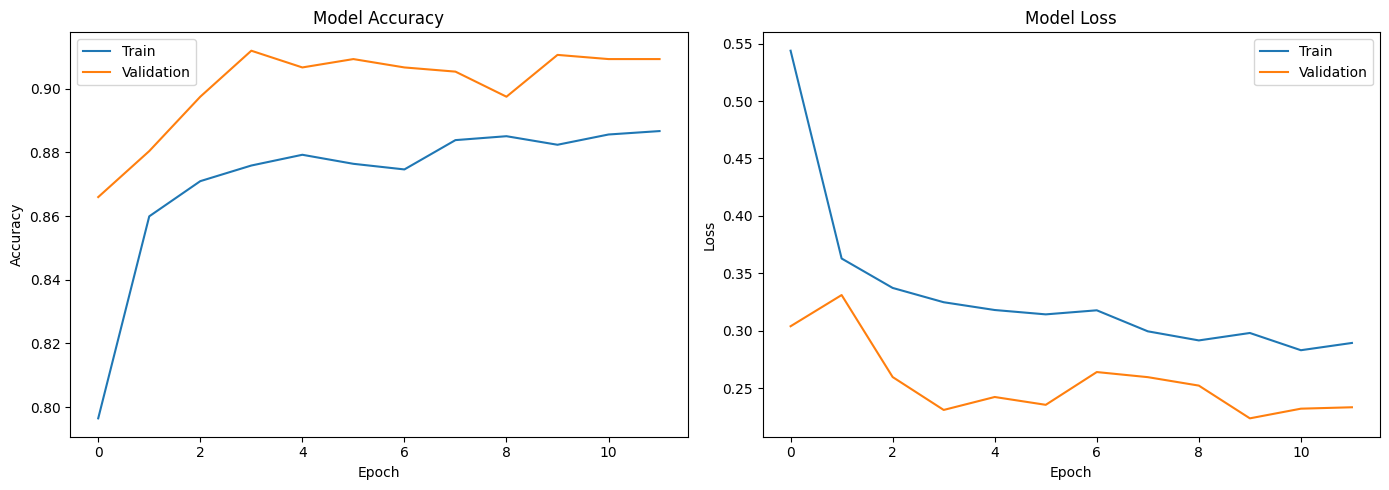

In [17]:
# =========================================
# Plot Accuracy and Loss
# =========================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])


plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.tight_layout()

plt.show()

In [18]:
# =========================================
# Evaluate Model
# =========================================

test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

print(f"Test Loss: {test_loss:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.8944 - loss: 0.2488
Test Accuracy: 90.05%
Test Loss: 0.2552


In [19]:
# =========================================
# Predictions
# =========================================

y_true = []

y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)

y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [20]:
# =========================================
# Metrics
# =========================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Accuracy  : {accuracy*100:.2f}%")

print(f"Precision : {precision*100:.2f}%")

print(f"Recall    : {recall*100:.2f}%")

print(f"F1 Score  : {f1*100:.2f}%")

Accuracy  : 90.05%
Precision : 90.39%
Recall    : 90.05%
F1 Score  : 89.99%


In [21]:
# =========================================
# Classification Report
# =========================================

report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES

)

print(report)

              precision    recall  f1-score   support

     UNKNOWN       0.86      0.91      0.89       548
   PNEUMONIA       0.88      0.94      0.91       427
TUBERCULOSIS       0.95      0.81      0.87       417
      NORMAL       1.00      1.00      1.00       135

    accuracy                           0.90      1527
   macro avg       0.92      0.92      0.92      1527
weighted avg       0.90      0.90      0.90      1527



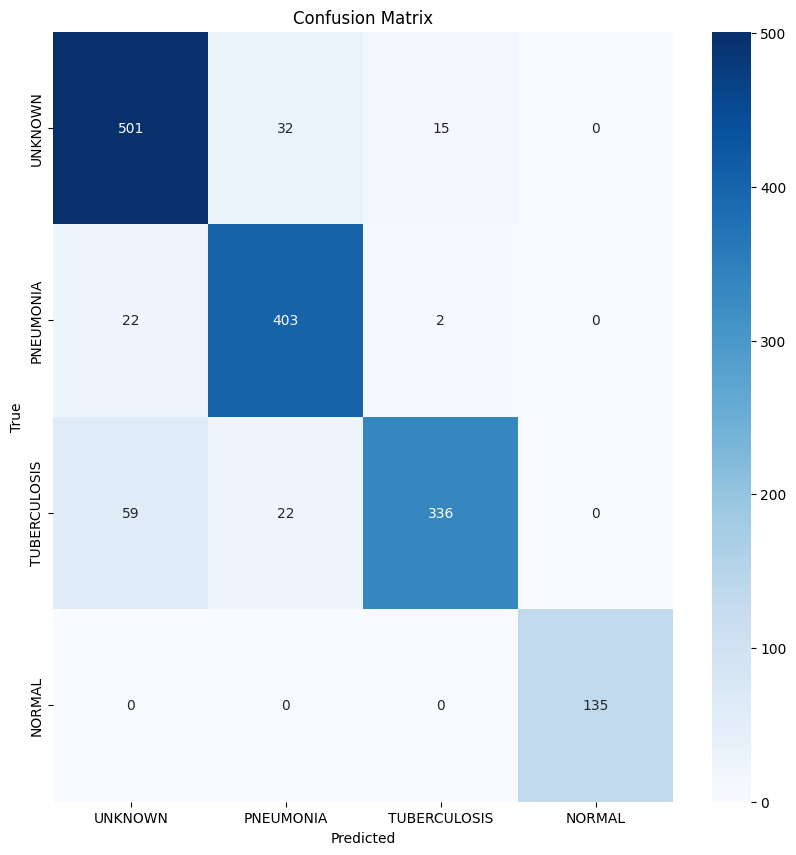

In [22]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

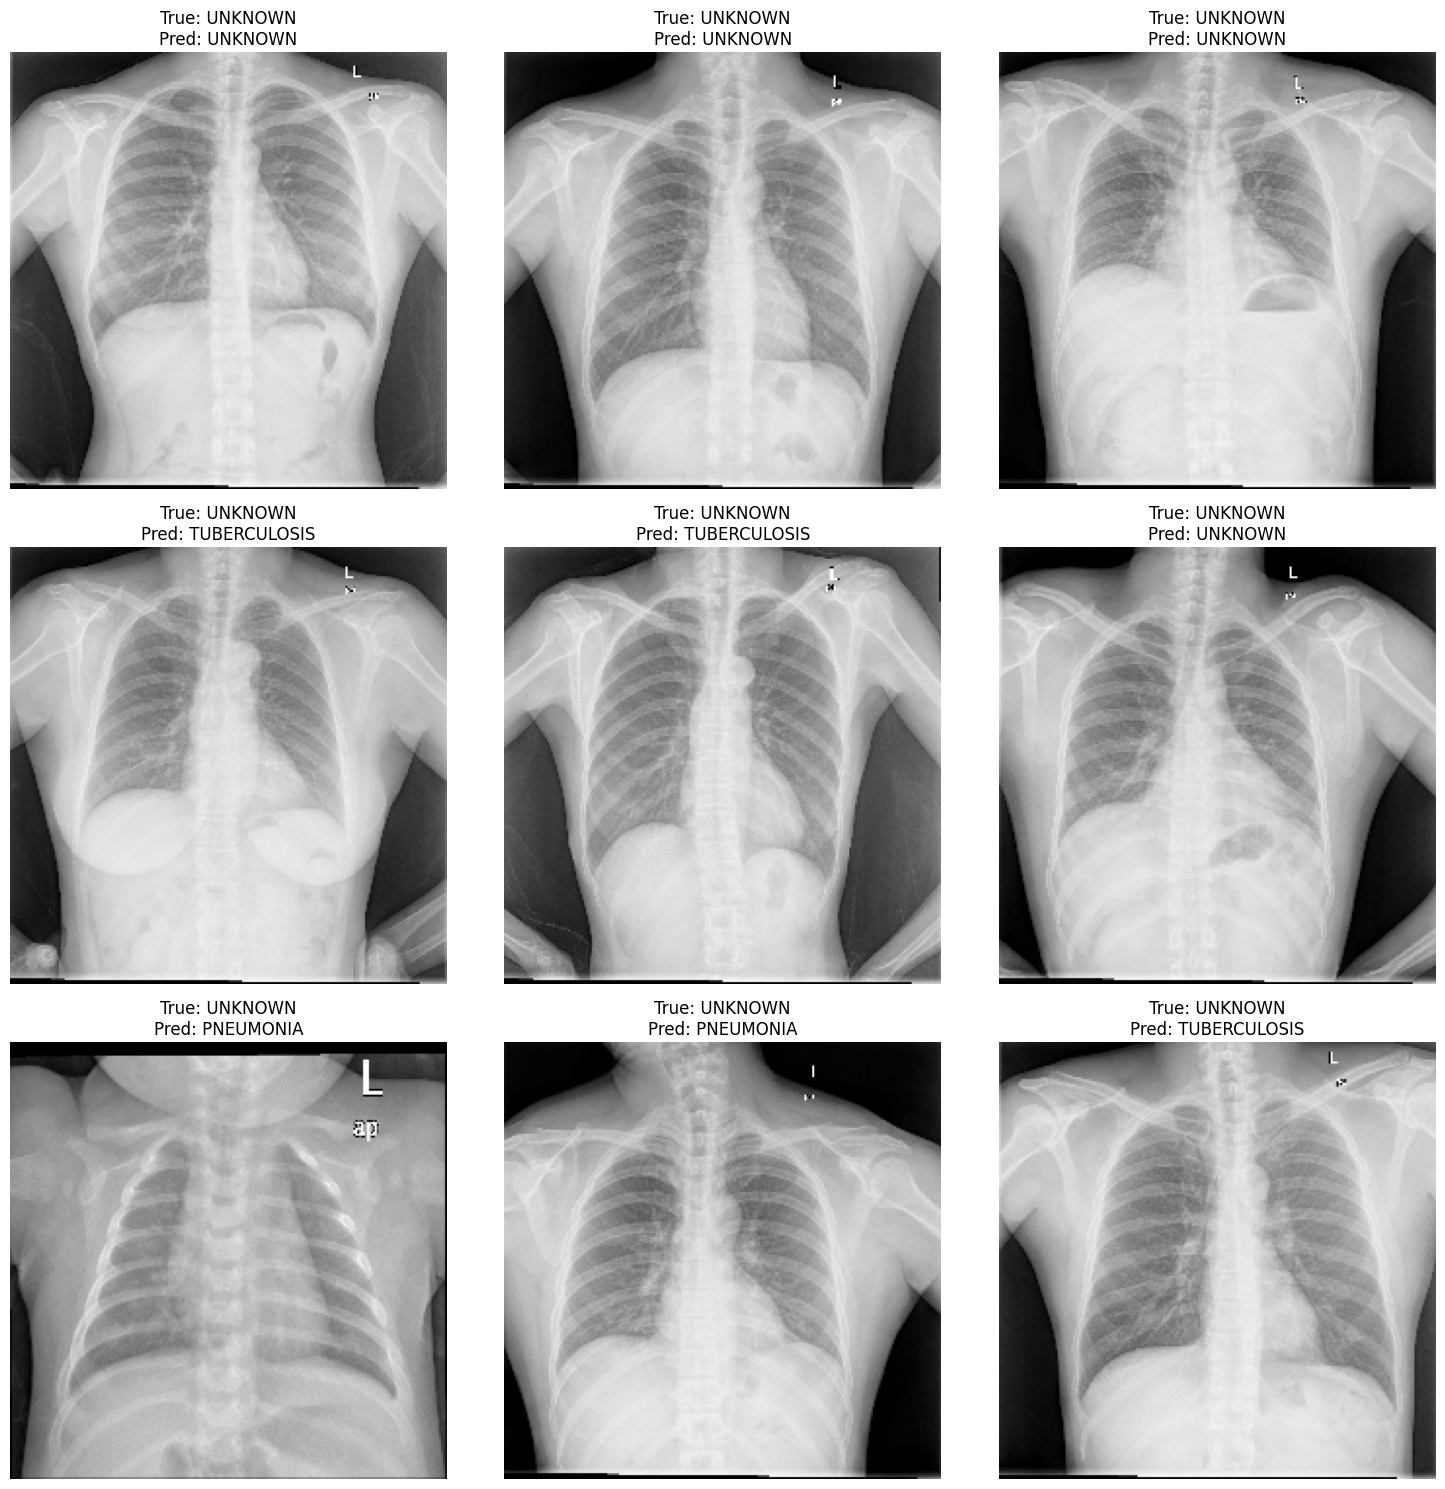

In [23]:
plt.figure(figsize=(15,15))

for images, labels in test_ds.take(1):

    for i in range(9):

        prediction = np.argmax(
            model.predict(
                np.expand_dims(images[i], axis=0),
                verbose=0
            )
        )

        plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(

            f"True: {CLASS_NAMES[labels[i]]}\n"
            f"Pred: {CLASS_NAMES[prediction]}"

        )

        plt.axis("off")

plt.tight_layout()

plt.show()

In [24]:
model.save(
    "/kaggle/working/medical_model.keras"
)

print("Model Saved Successfully")

Model Saved Successfully
